# ⚛️ Notebook 02: QAOA con Qiskit 2.4

**Herramienta:** Qiskit 2.4 + qiskit-algorithms + qiskit-optimization  
**Objetivo:** Resolver el Knapsack Problem usando QAOA (Quantum Approximate Optimization Algorithm)  
**Ejecución:** 100% local con `StatevectorSampler` (simulación exacta)  
**Tiempo estimado:** 20 minutos

---

## 1. Repaso Teórico: De ILP a QUBO

### Problema original (ILP)
$$\max \sum_{i=1}^{n} v_i x_i \quad \text{s.t.} \quad \sum_{i=1}^{n} w_i x_i \leq W, \quad x_i \in \{0,1\}$$

### Paso 1: Convertir a minimización
$$\min \;\; -\sum_{i=1}^{n} v_i x_i$$

### Paso 2: Incorporar restricción como penalización
$$\min \;\; -\sum_{i=1}^{n} v_i x_i + \lambda \left( \sum_{i=1}^{n} w_i x_i + s - W \right)^2$$

### Paso 3: Expansión binaria del slack
$$s = s_0 + 2s_1 + 4s_2 + 8s_3 \quad (s \in \{0, 1, \ldots, 15\})$$

### Forma QUBO final
$$\min \;\; -\sum_{i} v_i x_i + \lambda \left( \sum_{i} w_i x_i + \sum_{k=0}^{3} 2^k s_k - W \right)^2$$

> **Nota:** Qiskit Optimization hace esta conversión automáticamente. Aquí lo veremos paso a paso.

In [ ]:
# ------------------------------------------------------------------------------
# Notebook 02: QAOA Avanzado con la suite de Qiskit
# ------------------------------------------------------------------------------
!pip install -q qiskit              # Framework principal de IBM (Circuitos, Operadores)
!pip install -q qiskit-aer          # Simulador cuántico de alto rendimiento (AerSimulator)
!pip install -q qiskit-ibm-runtime  # Primitivas V2 (EstimatorV2 / SamplerV2)
!pip install -q qiskit-algorithms   # Algoritmos cuánticos variacionales (VQE, QAOA)
!pip install -q qiskit-optimization # Mapeo automático de problemas QUBO/Knapsack a Ising
!pip install -q pylatexenc          # Renderizado gráfico de circuitos con qc.draw('mpl')


## 2. Importar Librerías

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Qiskit core
import qiskit
from qiskit.primitives import StatevectorSampler

# Qiskit algorithms
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

# Qiskit optimization
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.applications import Knapsack

print(f"Qiskit versión: {qiskit.__version__}")

Qiskit versión: 2.2.1


## 3. Cargar la Instancia del Problema

In [ ]:
# Definición para Collab
knapsack_instance={
  "nombre": "Mochila - Ejemplo Didáctico (5 ítems)",
  "descripcion": "Instancia pequeña para demostración pedagógica. Solución óptima: ítems 3,4,5 con valor=31, peso=15.",
  "items": [
    {"id": 1, "nombre": "Laptop",    "valor": 5,  "peso": 3},
    {"id": 2, "nombre": "Cámara",    "valor": 10, "peso": 5},
    {"id": 3, "nombre": "Proyector", "valor": 15, "peso": 7},
    {"id": 4, "nombre": "Tablet",    "valor": 4,  "peso": 2},
    {"id": 5, "nombre": "Dron",      "valor": 12, "peso": 6}
  ],
  "capacidad": 15,
  "solucion_optima": {
    "items_seleccionados": [3, 4, 5],
    "valor_total": 31,
    "peso_total": 15
  },
  "notas": {
    "num_slack_bits": 4,
    "total_qubits": 9,
    "slack_rango": "0 a 15 (expansión binaria: s0 + 2*s1 + 4*s2 + 8*s3)"
  }
}

In [ ]:
with open('../data/knapsack_instance.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Para Collab
#data=knapsack_instance

items = data['items']
W = data['capacidad']
n = len(items)

valores = [item['valor'] for item in items]
pesos   = [item['peso']  for item in items]
nombres = [item['nombre'] for item in items]

print(f"Instancia: {n} ítems, capacidad W = {W}")
for item in items:
    print(f"  {item['nombre']:10s}  valor={item['valor']:2d}  peso={item['peso']}")

Instancia: 5 ítems, capacidad W = 15
  Laptop      valor= 5  peso=3
  Cámara      valor=10  peso=5
  Proyector   valor=15  peso=7
  Tablet      valor= 4  peso=2
  Dron        valor=12  peso=6


## 4. Formulación como Programa Cuadrático

Qiskit Optimization ofrece la clase `Knapsack` que crea automáticamente el `QuadraticProgram`.

In [3]:
# Método 1: Usando la clase Knapsack (automático)
knapsack = Knapsack(values=valores, weights=pesos, max_weight=W)
qp = knapsack.to_quadratic_program()

print("═" * 60)
print("PROGRAMA CUADRÁTICO (Quadratic Program)")
print("═" * 60)
print(qp.prettyprint())

════════════════════════════════════════════════════════════
PROGRAMA CUADRÁTICO (Quadratic Program)
════════════════════════════════════════════════════════════
Problem name: Knapsack

Maximize
  5*x_0 + 10*x_1 + 15*x_2 + 4*x_3 + 12*x_4

Subject to
  Linear constraints (1)
    3*x_0 + 5*x_1 + 7*x_2 + 2*x_3 + 6*x_4 <= 15  'c0'

  Binary variables (5)
    x_0 x_1 x_2 x_3 x_4



## 5. Conversión a QUBO

El conversor `QuadraticProgramToQubo` transforma el problema con restricciones
en un problema **sin restricciones** (QUBO), incorporando las restricciones como penalizaciones cuadráticas.

In [4]:
# Convertir a QUBO (Quadratic Unconstrained Binary Optimization)
converter = QuadraticProgramToQubo()
qubo = converter.convert(qp)

print("═" * 60)
print("FORMULACIÓN QUBO")
print("═" * 60)
print(qubo.prettyprint())

print(f"\nNúmero de variables binarias: {qubo.get_num_vars()}")
print(f"  - Variables de ítem: {n}")
print(f"  - Variables de slack: {qubo.get_num_vars() - n}")
print(f"  - Total de qubits necesarios: {qubo.get_num_vars()}")

════════════════════════════════════════════════════════════
FORMULACIÓN QUBO
════════════════════════════════════════════════════════════
Problem name: Knapsack

Minimize
  47*c0@int_slack@0^2 + 188*c0@int_slack@0*c0@int_slack@1
  + 376*c0@int_slack@0*c0@int_slack@2 + 752*c0@int_slack@0*c0@int_slack@3
  + 188*c0@int_slack@1^2 + 752*c0@int_slack@1*c0@int_slack@2
  + 1504*c0@int_slack@1*c0@int_slack@3 + 752*c0@int_slack@2^2
  + 3008*c0@int_slack@2*c0@int_slack@3 + 3008*c0@int_slack@3^2
  + 282*x_0*c0@int_slack@0 + 564*x_0*c0@int_slack@1 + 1128*x_0*c0@int_slack@2
  + 2256*x_0*c0@int_slack@3 + 423*x_0^2 + 1410*x_0*x_1 + 1974*x_0*x_2
  + 564*x_0*x_3 + 1692*x_0*x_4 + 470*x_1*c0@int_slack@0 + 940*x_1*c0@int_slack@1
  + 1880*x_1*c0@int_slack@2 + 3760*x_1*c0@int_slack@3 + 1175*x_1^2
  + 3290*x_1*x_2 + 940*x_1*x_3 + 2820*x_1*x_4 + 658*x_2*c0@int_slack@0
  + 1316*x_2*c0@int_slack@1 + 2632*x_2*c0@int_slack@2 + 5264*x_2*c0@int_slack@3
  + 2303*x_2^2 + 1316*x_2*x_3 + 3948*x_2*x_4 + 188*x_3*c0@int_s

## 6. Hamiltoniano Ising

Para ejecutar en un computador cuántico, convertimos el QUBO al **Hamiltoniano Ising**:

$$x_i = \frac{1 - Z_i}{2} \implies H_C = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j + c$$

In [5]:
# Obtener el operador Ising
ising_op, offset = qubo.to_ising()

print("═" * 60)
print("HAMILTONIANO ISING (H_C)")
print("═" * 60)
print(f"\nOffset (constante): {offset:.4f}")
print(f"Número de qubits: {ising_op.num_qubits}")
print(f"\nOperador (primeros términos):")

# Mostrar los términos del Hamiltoniano
terms = str(ising_op).split('\n')
for term in terms[:15]:  # Mostrar primeros 15 términos
    print(f"  {term}")
if len(terms) > 15:
    print(f"  ... ({len(terms) - 15} términos más)")

════════════════════════════════════════════════════════════
HAMILTONIANO ISING (H_C)
════════════════════════════════════════════════════════════

Offset (constante): 3173.0000
Número de qubits: 9

Operador (primeros términos):
  SparsePauliOp(['IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIZIIZ', 'IIIIZIIIZ', 'IIIZIIIIZ', 'IIZIIIIIZ', 'IZIIIIIIZ', 'ZIIIIIIIZ', 'IIIIIIZZI', 'IIIIIZIZI', 'IIIIZIIZI', 'IIIZIIIZI', 'IIZIIIIZI', 'IZIIIIIZI', 'ZIIIIIIZI', 'IIIIIZZII', 'IIIIZIZII', 'IIIZIIZII', 'IIZIIIZII', 'IZIIIIZII', 'ZIIIIIZII', 'IIIIZZIII', 'IIIZIZIII', 'IIZIIZIII', 'IZIIIZIII', 'ZIIIIZIII', 'IIIZZIIII', 'IIZIZIIII', 'IZIIZIIII', 'ZIIIZIIII', 'IIZZIIIII', 'IZIZIIIII', 'ZIIZIIIII', 'IZZIIIIII', 'ZIZIIIIII', 'ZZIIIIIII'],
                coeffs=[ -561.5+0.j,  -935. +0.j, -1308.5+0.j,  -374. +0.j, -1122. +0.j,
    -188. +0.j,  -376. +0.j,  -752. +0.j, -1504. +0.j,   352.5+0.j,
     493.5+

## 7. Configurar y Ejecutar QAOA

QAOA construye un circuito variacional con $p$ capas:

$$|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle = \prod_{l=1}^{p} e^{-i\beta_l H_M} \, e^{-i\gamma_l H_C} \, |+\rangle^{\otimes n}$$

- $H_C$: Hamiltoniano de costo (nuestro problema)
- $H_M = \sum_i X_i$: Hamiltoniano de mezcla
- $\gamma_l, \beta_l$: parámetros optimizados clásicamente

In [6]:
# Configurar primitiva de muestreo (simulación local exacta)
sampler = StatevectorSampler()

# Optimizador clásico para los parámetros variacionales
optimizer = COBYLA(maxiter=200)
repsqaoa= 2
# Crear instancia QAOA
# reps = número de capas p del circuito variacional
qaoa = QAOA(
    sampler=sampler,
    optimizer=optimizer,
    reps=repsqaoa              # p = 2 capas
)

print("Configuración QAOA:")
print(f"  Sampler:      StatevectorSampler (simulación local)")
print(f"  Optimizador:  COBYLA (max 200 iteraciones)")
print(f"  Capas (p):    2")
print(f"  Parámetros:   {2 ** repsqaoa} (2 γ + 2 β)")

Configuración QAOA:
  Sampler:      StatevectorSampler (simulación local)
  Optimizador:  COBYLA (max 200 iteraciones)
  Capas (p):    2
  Parámetros:   4 (2 γ + 2 β)


In [7]:
# Resolver usando MinimumEigenOptimizer como wrapper
meo = MinimumEigenOptimizer(qaoa)

print("Ejecutando QAOA... (esto puede tomar unos segundos)")
result = meo.solve(qp)

print("\n" + "═" * 60)
print("RESULTADO QAOA")
print("═" * 60)
print(result.prettyprint())

Ejecutando QAOA... (esto puede tomar unos segundos)


c:\ProgramData\anaconda3\envs\qhub\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\ProgramData\anaconda3\envs\qhub\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\ProgramData\anaconda3\envs\qhub\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



════════════════════════════════════════════════════════════
RESULTADO QAOA
════════════════════════════════════════════════════════════
objective function value: 31.0
variable values: x_0=0.0, x_1=0.0, x_2=1.0, x_3=1.0, x_4=1.0
status: SUCCESS


## 8. Interpretar Resultados

In [8]:
# Extraer la solución
solucion = result.x[:n]  # Solo las variables de ítem (no las slack)

print("\n🎯 SOLUCIÓN QAOA:")
print(f"{'─'*50}")

valor_qaoa = 0
peso_qaoa = 0

for i in range(n):
    sel = int(solucion[i])
    marca = '✅' if sel else '  '
    print(f"  {marca} x_{i+1} = {sel}  │  {nombres[i]:10s}  │  valor={valores[i]:2d}  │  peso={pesos[i]}")
    if sel:
        valor_qaoa += valores[i]
        peso_qaoa += pesos[i]

print(f"{'─'*50}")
print(f"  Valor total QAOA:  {valor_qaoa}")
print(f"  Peso total:        {peso_qaoa} / {W}")
print(f"  Valor óptimo real: 31")
print(f"  ¿Encontró óptimo?: {'✅ Sí' if valor_qaoa == 31 else '⚠️ Subóptimo (aproximación)'}")


🎯 SOLUCIÓN QAOA:
──────────────────────────────────────────────────
     x_1 = 0  │  Laptop      │  valor= 5  │  peso=3
     x_2 = 0  │  Cámara      │  valor=10  │  peso=5
  ✅ x_3 = 1  │  Proyector   │  valor=15  │  peso=7
  ✅ x_4 = 1  │  Tablet      │  valor= 4  │  peso=2
  ✅ x_5 = 1  │  Dron        │  valor=12  │  peso=6
──────────────────────────────────────────────────
  Valor total QAOA:  31
  Peso total:        15 / 15
  Valor óptimo real: 31
  ¿Encontró óptimo?: ✅ Sí


## 9. Visualización

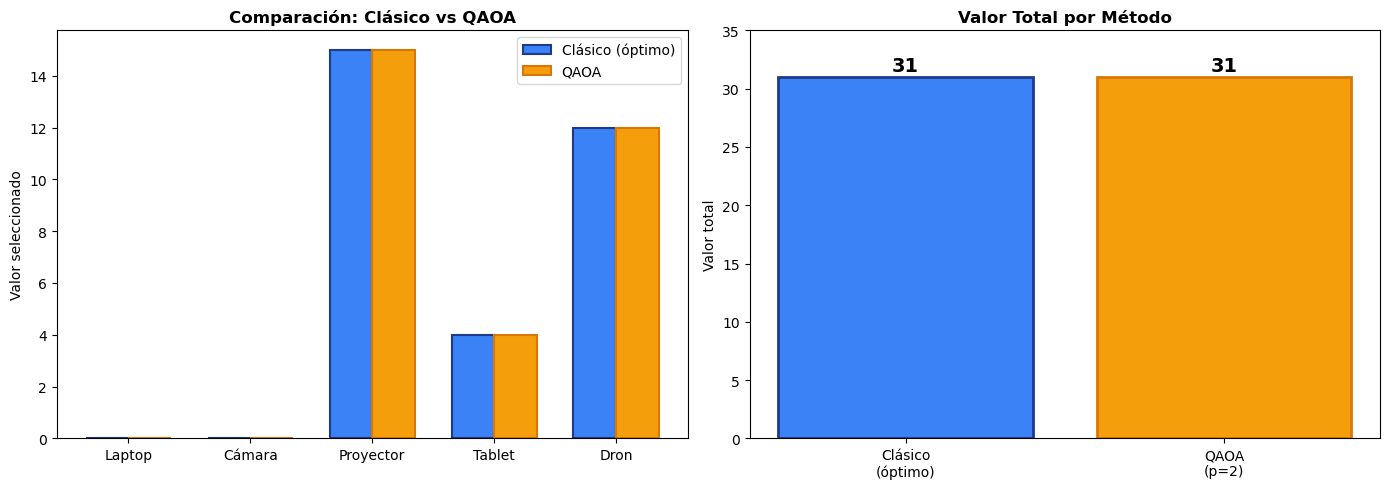

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: Comparación de selección ---
clasico = [0, 0, 1, 1, 1]  # Solución óptima conocida
qaoa_sel = [int(s) for s in solucion]

x_pos = np.arange(n)
width = 0.35

axes[0].bar(x_pos - width/2, [v*c for v, c in zip(valores, clasico)],
            width, label='Clásico (óptimo)', color='#3B82F6', edgecolor='#1E3A8A', linewidth=1.5)
axes[0].bar(x_pos + width/2, [v*q for v, q in zip(valores, qaoa_sel)],
            width, label='QAOA', color='#F59E0B', edgecolor='#D97706', linewidth=1.5)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(nombres, fontsize=10)
axes[0].set_ylabel('Valor seleccionado')
axes[0].set_title('Comparación: Clásico vs QAOA', fontweight='bold')
axes[0].legend()

# --- Gráfica 2: Resumen de valores ---
metodos = ['Clásico\n(óptimo)', 'QAOA\n(p=2)']
val_totales = [31, valor_qaoa]
colores = ['#3B82F6', '#F59E0B']

bars = axes[1].bar(metodos, val_totales, color=colores,
                    edgecolor=['#1E3A8A', '#D97706'], linewidth=2)
axes[1].set_ylabel('Valor total')
axes[1].set_title('Valor Total por Método', fontweight='bold')
axes[1].set_ylim(0, 35)

for bar, val in zip(bars, val_totales):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 10. Conclusiones

| Aspecto | Detalle |
|---------|--------|
| **Algoritmo** | QAOA (Quantum Approximate Optimization Algorithm) |
| **Tipo** | Variacional / Heurístico (no garantiza óptimo) |
| **Qubits** | 9 (5 ítems + 4 slack) |
| **Capas (p)** | 2 (más capas → mejor aproximación, más costo) |
| **Ejecución** | Simulación local con StatevectorSampler |

### ¿Cuándo usar QAOA?
- Cuando el problema es demasiado grande para solvers exactos
- Cuando se tiene acceso a hardware cuántico real
- Como puente entre optimización clásica y cuántica

### Siguiente paso
En el **Notebook 03**, resolveremos este mismo problema usando **Quantum Annealing con D-Wave**.